In [1]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path

from blinksdistance import BlinkDistance

In [2]:
def generate_webgazer_dataframe(df):
    df1 = df[df["trial_type"] == "html-keyboard-response"]
    df_webgazer = df1[~df1["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        json_data = df_webgazer["webgazer_data"].iloc[row].replace("'", "\"")
        data_list = json.loads(json_data)
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)


In [4]:
# This can load all data but is not storing df_webgazer in any place
files = Path("./data/all-exp-separados/").glob("*.csv")
dfs = []
i = 0
for file in files:
    if "blink" in str(file):
        print(file)
        df = pd.read_csv(file)
        df_tmp = generate_webgazer_dataframe(df)
        print(len(df_tmp))
        df_tmp["experiment"] = i
        df_tmp["file_name"] = str(file)
        i+=1
        dfs.append(df_tmp)

df_webgazer = pd.concat(dfs)
print(len(df_webgazer))

data/all-exp-separados/dataframe_blink_22.csv
1944
data/all-exp-separados/dataframe_blink_9.csv
743
data/all-exp-separados/dataframe_blink_8.csv
1206
data/all-exp-separados/dataframe_blink_23.csv
1480
data/all-exp-separados/dataframe_blink_21.csv
1974
data/all-exp-separados/dataframe_blink_20.csv
1584
data/all-exp-separados/dataframe_blink_18.csv
2598
data/all-exp-separados/dataframe_blink_24.csv
1894
data/all-exp-separados/dataframe_blink_25.csv
1843
data/all-exp-separados/dataframe_blink_19.csv
785
data/all-exp-separados/dataframe_blink_17.csv
490
data/all-exp-separados/dataframe_blink_1.csv
1417
data/all-exp-separados/dataframe_blink_16.csv
1558
data/all-exp-separados/dataframe_blink_14.csv
1476
data/all-exp-separados/dataframe_blink_3.csv
2880
data/all-exp-separados/dataframe_blink_2.csv
2361
data/all-exp-separados/dataframe_blink_15.csv
1937
data/all-exp-separados/dataframe_blink_11.csv
2162
data/all-exp-separados/dataframe_blink_6.csv
1343
data/all-exp-separados/dataframe_blink_7

In [5]:
blinkDistance = distance.BlinkDistance()

df_webgazer["isBlinkByDistance"] = df_webgazer["importantKeypoints"].map(
    lambda x: blinkDistance.isBlinkByDistance(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)


# df_webgazer['isBlinkByDistance'] = df_webgazer['importantKeypoints'].map(lambda x: isBlinkByEar(x['rightEyeTopArc'], x['rightEyeBottomArc'], x['leftEyeTopArc'], x['leftEyeBottomArc']))

df_webgazer

,x,y,t,importantKeypoints,dz,trial,experiment,file_name,isBlinkByDistance
0,0,0,6,"{'noseX': 299.44, 'noseY': 285.45, 'topY': 174...",59.37,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal..."
1,0,0,40,"{'noseX': 299.86, 'noseY': 284.82, 'topY': 174...",56.06,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal..."
2,0,0,74,"{'noseX': 300.63, 'noseY': 285.45, 'topY': 173...",53.35,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal..."
3,0,0,106,"{'noseX': 301.08, 'noseY': 285.31, 'topY': 173...",51.42,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal..."
4,0,0,141,"{'noseX': 301.66, 'noseY': 285.31, 'topY': 173...",50.71,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...,...,...,...,...
251,0,0,8543,"{'noseX': 390, 'noseY': 299.17, 'topY': 162.47...",42.36,6,24,data/all-exp-separados/dataframe_blink_13.csv,"[False, False, False, False, False, False, Fal..."
252,0,0,8578,"{'noseX': 386.91, 'noseY': 297.21, 'topY': 161...",43.42,6,24,data/all-exp-separados/dataframe_blink_13.csv,"[False, False, False, False, False, False, Fal..."
253,0,0,8612,"{'noseX': 381.07, 'noseY': 298.49, 'topY': 161...",41.85,6,24,data/all-exp-separados/dataframe_blink_13.csv,"[False, False, False, False, False, False, Fal..."
254,0,0,8644,"{'noseX': 377.21, 'noseY': 297.19, 'topY': 160...",40.99,6,24,data/all-exp-separados/dataframe_blink_13.csv,"[False, False, False, False, False, False, Fal..."


In [6]:
df_webgazer["isBlinkByDistance"].apply(lambda x: len(x)).head()

0    15
1    15
2    15
3    15
4    15
Name: isBlinkByDistance, dtype: int64

In [7]:
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[1]==True))
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[2]==True))
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[4]==True))
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[5]==True))
df_webgazer["Blink_sample6"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[6]==True))
df_webgazer["Blink_sample7"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[7]==True))
df_webgazer["Blink_sample8"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[8]==True))
df_webgazer["Blink_sample9"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[9]==True))
df_webgazer["Blink_sample10"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[10]==True))
df_webgazer["Blink_sample11"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[12]==True))
df_webgazer["Blink_sample12"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[13]==True))
df_webgazer["Blink_sample13"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[13]==True))
df_webgazer["Blink_sample14"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[14]==True))


In [8]:
df_webgazer.head()

,x,y,t,importantKeypoints,dz,trial,experiment,file_name,isBlinkByDistance,Blink_sample,...,Blink_sample5,Blink_sample6,Blink_sample7,Blink_sample8,Blink_sample9,Blink_sample10,Blink_sample11,Blink_sample12,Blink_sample13,Blink_sample14
0,0,0,6,"{'noseX': 299.44, 'noseY': 285.45, 'topY': 174...",59.37,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...",0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,40,"{'noseX': 299.86, 'noseY': 284.82, 'topY': 174...",56.06,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...",0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,74,"{'noseX': 300.63, 'noseY': 285.45, 'topY': 173...",53.35,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...",0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,106,"{'noseX': 301.08, 'noseY': 285.31, 'topY': 173...",51.42,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...",0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,141,"{'noseX': 301.66, 'noseY': 285.31, 'topY': 173...",50.71,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...",0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
## Resultados por trial y persona

df_webgazer["Blink_sample0_diff"] = (df_webgazer['Blink_sample'].shift(1)+1 == df_webgazer['Blink_sample'])
df_webgazer["Blink_sample1_diff"] = (df_webgazer['Blink_sample1'].shift(1)+1 == df_webgazer['Blink_sample1'])
df_webgazer["Blink_sample2_diff"] = (df_webgazer['Blink_sample2'].shift(1)+1 == df_webgazer['Blink_sample2'])
df_webgazer["Blink_sample3_diff"] = (df_webgazer['Blink_sample3'].shift(1)+1 == df_webgazer['Blink_sample3'])
df_webgazer["Blink_sample4_diff"] = (df_webgazer['Blink_sample4'].shift(1)+1 == df_webgazer['Blink_sample4'])
df_webgazer["Blink_sample5_diff"] = (df_webgazer['Blink_sample5'].shift(1)+1 == df_webgazer['Blink_sample5'])
df_webgazer["Blink_sample6_diff"] = (df_webgazer['Blink_sample6'].shift(1)+1 == df_webgazer['Blink_sample6'])
df_webgazer["Blink_sample7_diff"] = (df_webgazer['Blink_sample7'].shift(1)+1 == df_webgazer['Blink_sample7'])
df_webgazer["Blink_sample8_diff"] = (df_webgazer['Blink_sample8'].shift(1)+1 == df_webgazer['Blink_sample8'])
df_webgazer["Blink_sample9_diff"] = (df_webgazer['Blink_sample9'].shift(1)+1 == df_webgazer['Blink_sample9'])
df_webgazer["Blink_sample10_diff"] = (df_webgazer['Blink_sample10'].shift(1)+1 == df_webgazer['Blink_sample10'])
df_webgazer["Blink_sample11_diff"] = (df_webgazer['Blink_sample11'].shift(1)+1 == df_webgazer['Blink_sample11'])
df_webgazer["Blink_sample12_diff"] = (df_webgazer['Blink_sample12'].shift(1)+1 == df_webgazer['Blink_sample12'])
df_webgazer["Blink_sample13_diff"] = (df_webgazer['Blink_sample13'].shift(1)+1 == df_webgazer['Blink_sample13'])
df_webgazer["Blink_sample14_diff"] = (df_webgazer['Blink_sample14'].shift(1)+1 == df_webgazer['Blink_sample14'])

results = []
for x in range(0,15):
    tmp_result = df_webgazer.groupby(['trial', 'file_name'])['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

cleaned_results = [results[0]] + [df.drop(columns=['trial', 'file_name']) for df in results[1:]]
result = pd.concat(cleaned_results, axis=1)
result

,trial,file_name,Blink_sample0_diff,Blink_sample1_diff,Blink_sample2_diff,Blink_sample3_diff,Blink_sample4_diff,Blink_sample5_diff,Blink_sample6_diff,Blink_sample7_diff,Blink_sample8_diff,Blink_sample9_diff,Blink_sample10_diff,Blink_sample11_diff,Blink_sample12_diff,Blink_sample13_diff,Blink_sample14_diff
0,1,data/all-exp-separados/dataframe_blink_1.csv,0,9,10,0,11,10,10,10,10,10,10,10,10,10,10
1,1,data/all-exp-separados/dataframe_blink_10.csv,0,0,0,0,93,1,1,1,1,0,1,1,1,1,1
2,1,data/all-exp-separados/dataframe_blink_11.csv,0,10,6,0,10,10,10,10,10,9,10,10,10,10,10
3,1,data/all-exp-separados/dataframe_blink_12.csv,0,0,11,12,0,3,7,9,9,10,3,8,9,9,9
4,1,data/all-exp-separados/dataframe_blink_13.csv,0,0,12,10,11,12,12,12,12,12,12,12,12,12,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,6,data/all-exp-separados/dataframe_blink_5.csv,0,0,0,0,0,0,5,0,0,0,1,0,0,0,0
146,6,data/all-exp-separados/dataframe_blink_6.csv,4,10,0,0,11,9,8,0,0,0,12,0,0,0,0
147,6,data/all-exp-separados/dataframe_blink_7.csv,0,0,0,0,12,11,11,11,17,5,11,12,13,13,15
148,6,data/all-exp-separados/dataframe_blink_8.csv,0,0,14,13,10,11,9,11,11,15,9,10,9,9,11


In [ ]:
threshold_columns

In [10]:
threshold_columns = [col for col in result.columns if col not in ['trial', 'file_name', 'should_be']]
result['should_be'] = result['trial'].apply(lambda x: 2 if x == 3 else 10)
result[result['trial']==3]


,trial,file_name,Blink_sample0_diff,Blink_sample1_diff,Blink_sample2_diff,Blink_sample3_diff,Blink_sample4_diff,Blink_sample5_diff,Blink_sample6_diff,Blink_sample7_diff,Blink_sample8_diff,Blink_sample9_diff,Blink_sample10_diff,Blink_sample11_diff,Blink_sample12_diff,Blink_sample13_diff,Blink_sample14_diff,should_be
50,3,data/all-exp-separados/dataframe_blink_1.csv,0,5,11,0,10,10,10,10,10,10,10,10,10,10,10,2
51,3,data/all-exp-separados/dataframe_blink_10.csv,0,0,0,0,97,0,0,0,0,0,0,0,0,0,0,2
52,3,data/all-exp-separados/dataframe_blink_11.csv,0,4,7,0,2,2,2,2,2,2,2,2,2,2,2,2
53,3,data/all-exp-separados/dataframe_blink_12.csv,0,0,4,3,0,0,0,0,0,0,0,0,0,0,0,2
54,3,data/all-exp-separados/dataframe_blink_13.csv,0,0,4,3,2,3,4,4,4,4,4,4,4,4,4,2
55,3,data/all-exp-separados/dataframe_blink_14.csv,0,0,2,2,5,4,5,2,2,3,4,3,3,3,2,2
56,3,data/all-exp-separados/dataframe_blink_15.csv,0,13,2,0,2,2,2,2,6,2,2,2,2,2,4,2
57,3,data/all-exp-separados/dataframe_blink_16.csv,0,0,2,2,9,6,3,2,2,2,3,2,2,2,2,2
58,3,data/all-exp-separados/dataframe_blink_17.csv,0,2,0,0,3,2,2,2,2,2,2,2,2,2,2,2
59,3,data/all-exp-separados/dataframe_blink_18.csv,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2


In [12]:
THRESHOLDS = [0.15, 0.25, 0.6, 0.75, 0.4, 0.42,
                          0.45, 0.5, 0.52, 0.55, 0.44, 0.46, 0.48, 0.49, 0.51]


results_global = []

for i, threshold in enumerate(threshold_columns):
    preds = result[threshold]
    truth = result['should_be']
    mae = np.mean(np.abs(preds - truth))
    rmse = np.sqrt(np.mean((preds - truth) ** 2))
    results_global.append({'Threshold': THRESHOLDS[i], 'Error Absoluto Medio': mae, 'Error Cuadrático Medio': rmse})

results_global_df = pd.DataFrame(results_global).sort_values(by='Error Cuadrático Medio')

results_global_df.head()

,Threshold,Error Absoluto Medio,Error Cuadrático Medio
12,0.48,3.626667,5.507571
13,0.49,3.626667,5.507571
11,0.46,3.633333,5.544367
7,0.50,3.780000,5.591064
5,0.42,3.553333,5.756735


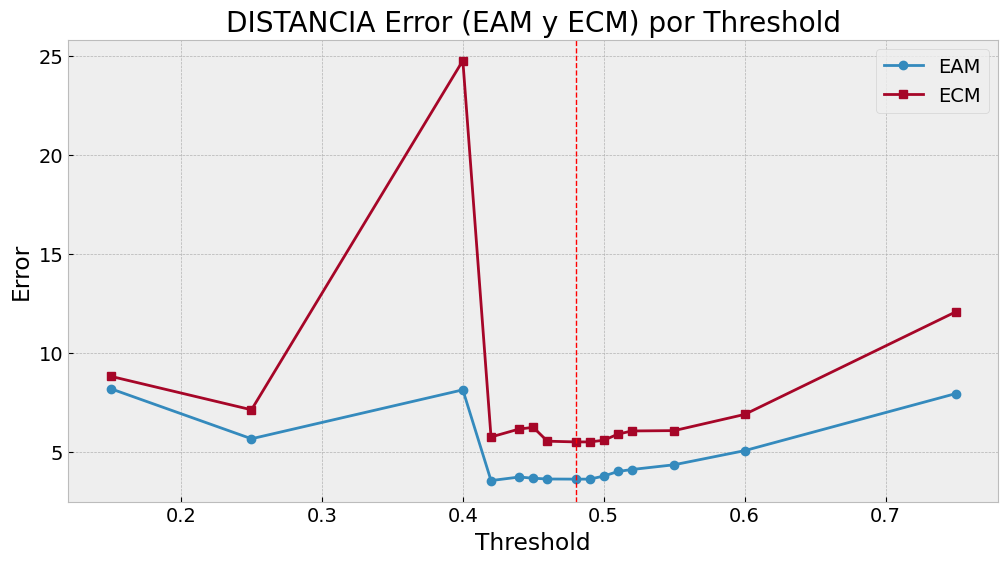

In [13]:
# Calcular MAE y RMSE por threshold
results = []
metodo = "DISTANCIA"
plt.style.use('bmh')
THRESHOLDS = [0.15, 0.25, 0.6, 0.75, 0.4, 0.42,
                          0.45, 0.5, 0.52, 0.55, 0.44, 0.46, 0.48, 0.49, 0.51]
for i, threshold in enumerate(threshold_columns):
    preds = result[threshold]
    truth = result['should_be']
    mae = np.mean(np.abs(preds - truth))
    rmse = np.sqrt(np.mean((preds - truth) ** 2))
    results.append({
        'Threshold': threshold,
        'Threshold_float': float(str(THRESHOLDS[i]).replace(",", ".").replace(" ", "")),
        'MAE': mae,
        'RMSE': rmse
    })

results_df = pd.DataFrame(results).sort_values('Threshold_float')
plt.rcParams['font.size'] = 14

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(results_df['Threshold_float'], results_df['MAE'], label='EAM', marker='o')
plt.plot(results_df['Threshold_float'], results_df['RMSE'], label='ECM', marker='s')
plt.xlabel("Threshold")
plt.ylabel("Error")
plt.axvline(0.48, color="red", linestyle="--", lw=1)
plt.title(metodo + " Error (EAM y ECM) por Threshold")
plt.legend()
plt.grid(True)
plt.show()
